In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('segmentation_df.csv')
df.head()

,household_key,total_sales_x,avg_sales,total_quantity,avg_quantity,avg_basket_size,total_orders,unique_visits_days,order_frequency,relative_recency,avg_days_between_visits,coupon_dependecy_ratio
0,1,4330.16,2.507331,1997,1.156340,23.220930,86,79,7.616279,6,8.397436,0.072399
1,2,1954.34,2.737171,834,1.168067,18.533333,45,45,12.555556,44,12.840909,0.010623
2,3,2653.21,2.877668,8540,9.262473,181.702128,47,46,12.553191,9,13.111111,0.071909
3,4,1200.11,3.987076,382,1.269103,12.733333,30,30,17.433333,85,18.034483,0.010416
4,5,779.06,3.509279,245,1.103604,6.125000,40,33,15.450000,9,19.312500,0.000000


In [3]:
df2 = df.drop(columns = ['household_key'], axis = 1)
df2.head()

,total_sales_x,avg_sales,total_quantity,avg_quantity,avg_basket_size,total_orders,unique_visits_days,order_frequency,relative_recency,avg_days_between_visits,coupon_dependecy_ratio
0,4330.16,2.507331,1997,1.156340,23.220930,86,79,7.616279,6,8.397436,0.072399
1,1954.34,2.737171,834,1.168067,18.533333,45,45,12.555556,44,12.840909,0.010623
2,2653.21,2.877668,8540,9.262473,181.702128,47,46,12.553191,9,13.111111,0.071909
3,1200.11,3.987076,382,1.269103,12.733333,30,30,17.433333,85,18.034483,0.010416
4,779.06,3.509279,245,1.103604,6.125000,40,33,15.450000,9,19.312500,0.000000


<Axes: >

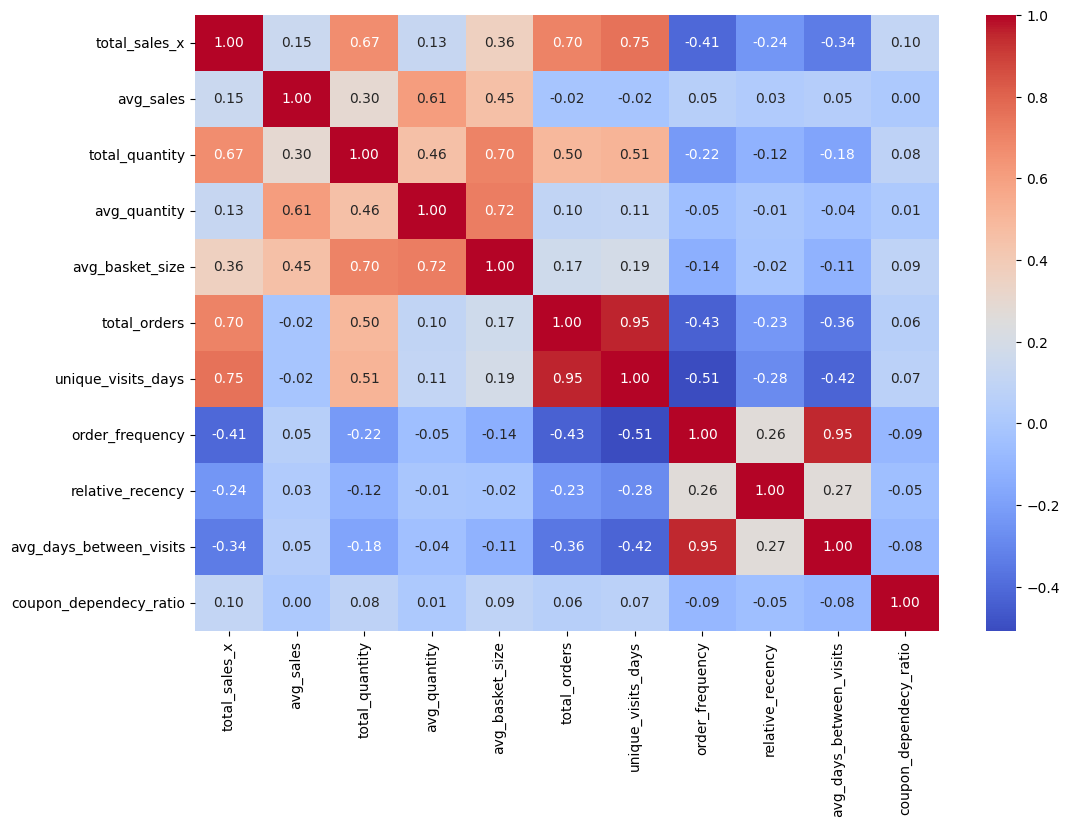

In [4]:
# heatmap to check multi-collinearity
plt.figure(figsize = (12, 8))
corr = df2.corr()
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm')

#### **VIF**

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif   

vif_values = [vif(df2.values, i) for i in range(df2.shape[1])]
vif_values



[np.float64(6.69458401225413),
 np.float64(6.821920157984497),
 np.float64(3.9292108190700987),
 np.float64(2.8983126921110727),
 np.float64(4.826013959223821),
 np.float64(22.281233506873996),
 np.float64(31.25573566695581),
 np.float64(17.359390095422622),
 np.float64(1.3212138907630653),
 np.float64(14.224088355841046),
 np.float64(1.2544385211238998)]

- Severe Multicollinearity. Some coefficients are values more than 5. They are highly unstable and hence PCA works well to reduce the dimensions 

**PCA - DIMENSIONALITY REDUCTION**

In [6]:
scaler = StandardScaler()
df2 = pd.DataFrame(scaler.fit_transform(df2), columns = df2.columns)
df2.head()

,total_sales_x,avg_sales,total_quantity,avg_quantity,avg_basket_size,total_orders,unique_visits_days,order_frequency,relative_recency,avg_days_between_visits,coupon_dependecy_ratio
0,0.330662,-0.642824,-0.418471,-0.374876,-0.567611,-0.212662,-0.146958,-0.342215,-0.327726,-0.310312,2.231985
1,-0.378886,-0.410892,-0.423229,-0.374828,-0.571393,-0.567192,-0.592555,-0.071914,0.277581,-0.150210,-0.085853
2,-0.170166,-0.269116,-0.391700,-0.341454,-0.439739,-0.549898,-0.579450,-0.072043,-0.279938,-0.140474,2.213599
3,-0.604140,0.850390,-0.425079,-0.374412,-0.576073,-0.696898,-0.789142,0.195021,0.930675,0.036920,-0.093612
4,-0.729888,0.368244,-0.425639,-0.375094,-0.581405,-0.610427,-0.749825,0.086484,-0.279938,0.082968,-0.484405


In [7]:
pca = PCA(n_components = 5)
principal_components = pca.fit_transform(df2)
principal_components

array([[-0.0526402 , -1.07756095, -0.4398194 ,  2.21031908, -0.08354625],
       [-1.05046645, -0.53930142, -0.42067547, -0.04908896,  0.26230387],
       [-0.62746872, -0.52773579, -0.67633626,  2.2222097 , -0.19785037],
       ...,
       [ 0.53180284, -1.03260086, -0.10381234, -0.62385487, -0.17781536],
       [ 0.40163131,  0.10482673, -0.49154359, -0.3736119 , -0.1917046 ],
       [ 1.48005638,  0.68803291, -0.65795841,  2.24944019, -0.08378188]],
      shape=(2500, 5))

In [8]:
eigen_values = pca.explained_variance_
eigen_values

array([4.09444282, 2.32188283, 1.25342652, 0.99157837, 0.86460474])

In [9]:
pca.explained_variance_ratio_

array([0.37207319, 0.21099583, 0.11390229, 0.09010743, 0.07856899])

In [10]:
cumulative_var = np.cumsum(eigen_values)
cumulative_var

array([4.09444282, 6.41632565, 7.66975217, 8.66133055, 9.52593528])

In [11]:
eigen_vectors = pca.components_
eigen_vectors

array([[ 0.41055621,  0.11749754,  0.37374256,  0.19693567,  0.27187228,
         0.39794261,  0.41978788, -0.32755377, -0.1702551 , -0.29904927,
         0.07047912],
       [-0.03989611,  0.46738783,  0.25861856,  0.49817477,  0.45403504,
        -0.17115821, -0.18690855,  0.28934584,  0.17206534,  0.28459171,
        -0.01405607],
       [ 0.27990303, -0.17908174,  0.18811573, -0.21606991, -0.11724632,
         0.35409389,  0.29758879,  0.49491167,  0.11453844,  0.55885279,
        -0.09720582],
       [ 0.03561438, -0.07382931,  0.03932595, -0.0845144 ,  0.0478003 ,
        -0.05200358, -0.04353259,  0.07989351, -0.02296735,  0.08346837,
         0.98174837],
       [ 0.02152605, -0.12924023,  0.05883734, -0.06095538,  0.05666167,
         0.05128468,  0.03045459, -0.18209184,  0.95330049, -0.16060583,
         0.03397893]])

In [12]:
new_df = pd.DataFrame(eigen_vectors.T, columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'], index = df2.columns)
new_df

,PC1,PC2,PC3,PC4,PC5
total_sales_x,0.410556,-0.039896,0.279903,0.035614,0.021526
avg_sales,0.117498,0.467388,-0.179082,-0.073829,-0.129240
total_quantity,0.373743,0.258619,0.188116,0.039326,0.058837
avg_quantity,0.196936,0.498175,-0.216070,-0.084514,-0.060955
avg_basket_size,0.271872,0.454035,-0.117246,0.047800,0.056662
total_orders,0.397943,-0.171158,0.354094,-0.052004,0.051285
unique_visits_days,0.419788,-0.186909,0.297589,-0.043533,0.030455
order_frequency,-0.327554,0.289346,0.494912,0.079894,-0.182092
relative_recency,-0.170255,0.172065,0.114538,-0.022967,0.953300
avg_days_between_visits,-0.299049,0.284592,0.558853,0.083468,-0.160606


In [13]:
new_df2 = pd.DataFrame(principal_components, columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
new_df2.head()

,PC1,PC2,PC3,PC4,PC5
0,-0.052640,-1.077561,-0.439819,2.210319,-0.083546
1,-1.050466,-0.539301,-0.420675,-0.049089,0.262304
2,-0.627469,-0.527736,-0.676336,2.222210,-0.197850
3,-1.385906,0.358717,-0.501671,-0.120931,0.625079
4,-1.244711,-0.107781,-0.536195,-0.456925,-0.464966


In [14]:
new_df2.shape

(2500, 5)

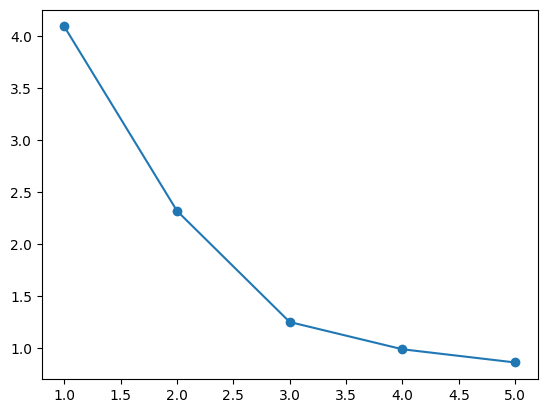

In [15]:
plt.plot(range(1, len(eigen_values) + 1), eigen_values, marker='o')
plt.show()

**CLUSTERING**

In [16]:
wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(new_df2)
    wcss.append(kmeans.inertia_)
wcss

[17885.10769362734,
 14704.174046508357,
 12922.829283701192,
 11506.944019391818,
 10190.373007434815,
 9086.769847788923,
 7896.194664208335,
 7149.64453199439,
 6571.822704527928]

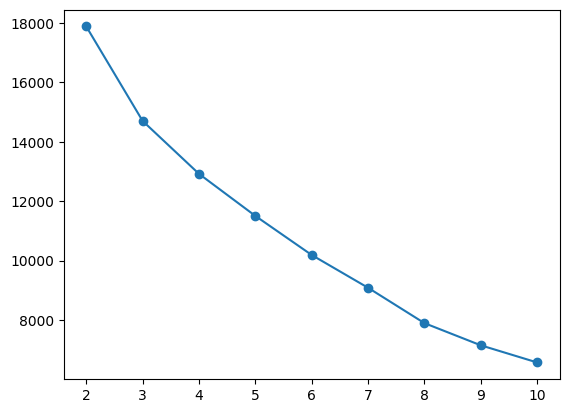

In [17]:
plt.plot(range(2, 11), wcss, marker='o')
plt.show()

In [18]:
scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    labels =kmeans.fit_predict(new_df2)
    scores.append(silhouette_score(new_df2,labels))
scores

[0.4145514687707643,
 0.45330244825340144,
 0.4439494791409674,
 0.2605326972363677,
 0.2756898282334323,
 0.3005926775635039,
 0.31239017621234144,
 0.2742499921627954,
 0.27831851722747036]

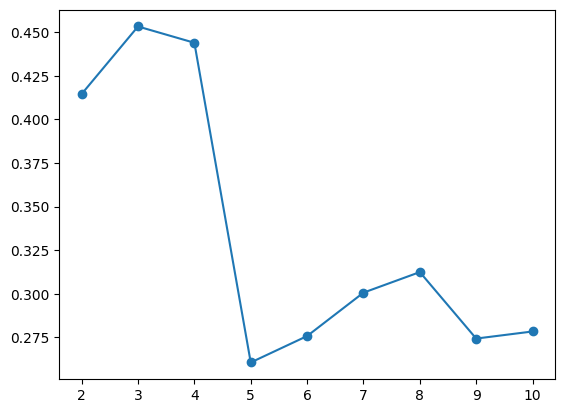

In [19]:
plt.plot(range(2, 11), scores, marker='o')
plt.show()

In [20]:
kmeans_3 = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
y_kmeans = kmeans_3.fit_predict(new_df2)
y_kmeans

array([1, 1, 1, ..., 1, 1, 0], shape=(2500,), dtype=int32)

In [21]:
new_df2['cluster'] = y_kmeans

In [22]:
new_df2.head()

,PC1,PC2,PC3,PC4,PC5,cluster
0,-0.052640,-1.077561,-0.439819,2.210319,-0.083546,1
1,-1.050466,-0.539301,-0.420675,-0.049089,0.262304,1
2,-0.627469,-0.527736,-0.676336,2.222210,-0.197850,1
3,-1.385906,0.358717,-0.501671,-0.120931,0.625079,1
4,-1.244711,-0.107781,-0.536195,-0.456925,-0.464966,1


In [23]:
new_df2['cluster'].value_counts()

cluster
1    1885
0     422
2     193
Name: count, dtype: int64

In [24]:
df2['cluster'] = y_kmeans
df2.head()

,total_sales_x,avg_sales,total_quantity,avg_quantity,avg_basket_size,total_orders,unique_visits_days,order_frequency,relative_recency,avg_days_between_visits,coupon_dependecy_ratio,cluster
0,0.330662,-0.642824,-0.418471,-0.374876,-0.567611,-0.212662,-0.146958,-0.342215,-0.327726,-0.310312,2.231985,1
1,-0.378886,-0.410892,-0.423229,-0.374828,-0.571393,-0.567192,-0.592555,-0.071914,0.277581,-0.150210,-0.085853,1
2,-0.170166,-0.269116,-0.391700,-0.341454,-0.439739,-0.549898,-0.579450,-0.072043,-0.279938,-0.140474,2.213599,1
3,-0.604140,0.850390,-0.425079,-0.374412,-0.576073,-0.696898,-0.789142,0.195021,0.930675,0.036920,-0.093612,1
4,-0.729888,0.368244,-0.425639,-0.375094,-0.581405,-0.610427,-0.749825,0.086484,-0.279938,0.082968,-0.484405,1


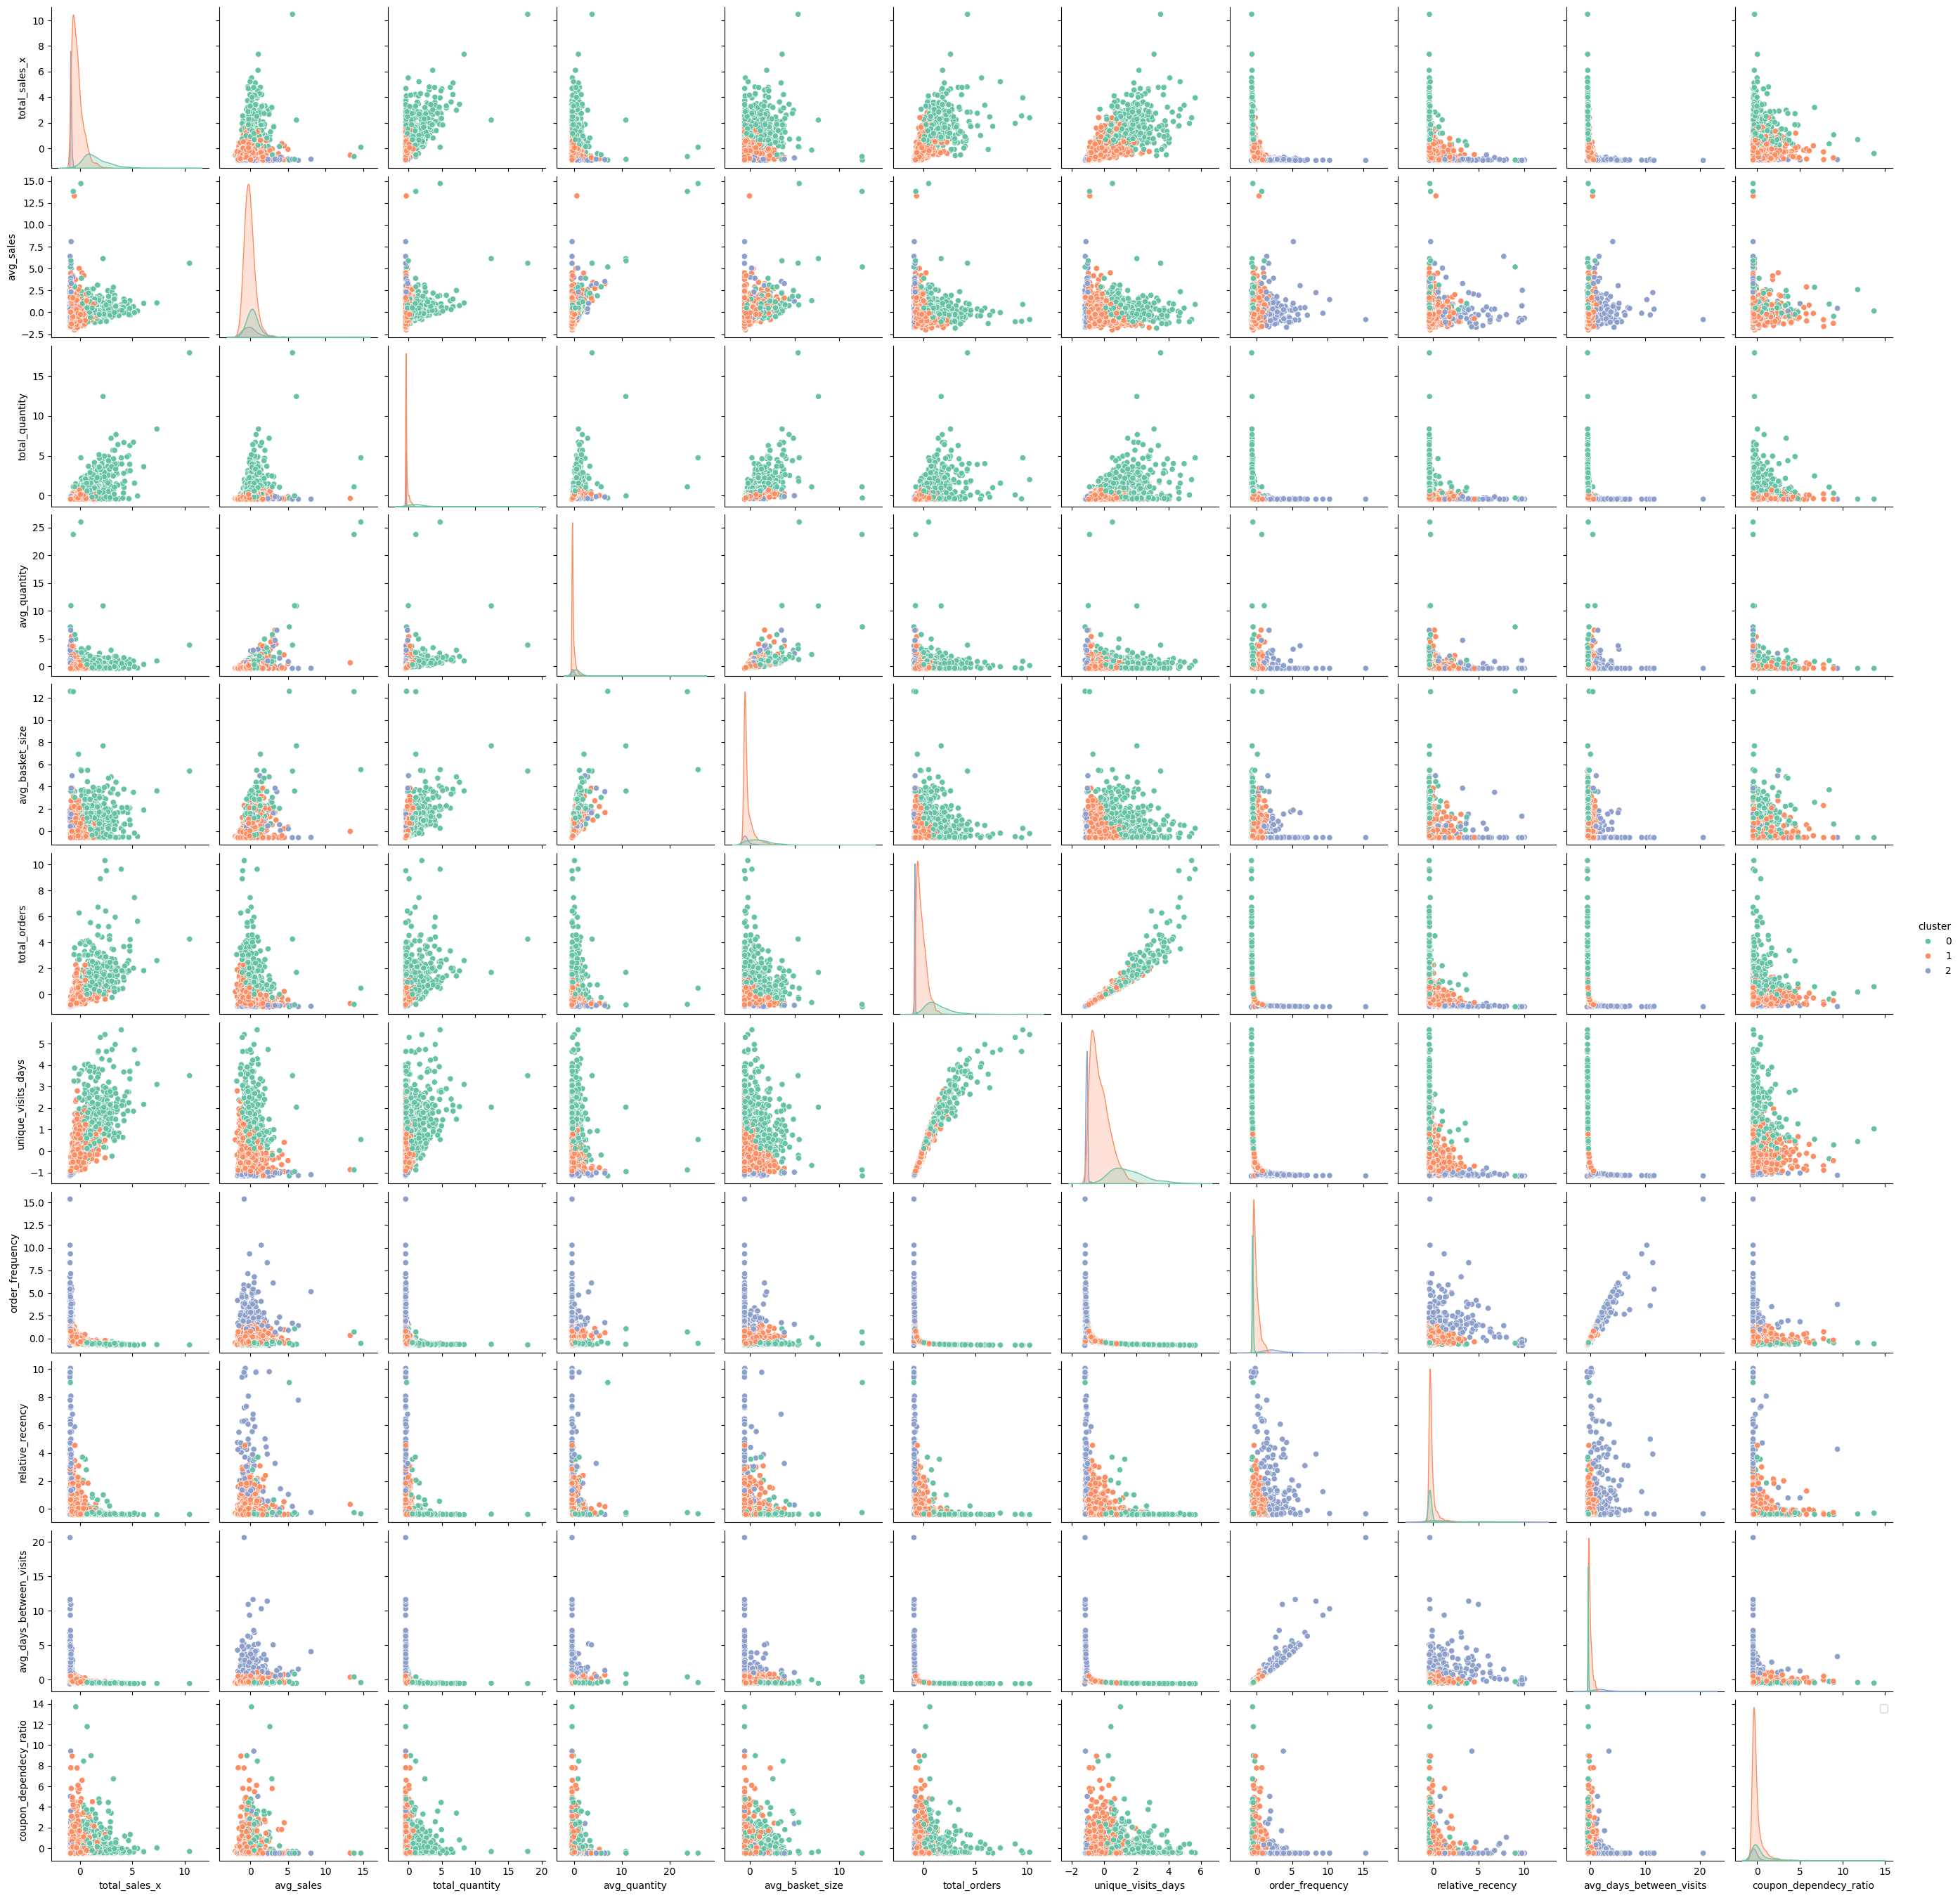

In [25]:
sns.pairplot(df2, hue='cluster',palette='Set2')
plt.legend()
plt.show()

In [26]:
df2.head()

,total_sales_x,avg_sales,total_quantity,avg_quantity,avg_basket_size,total_orders,unique_visits_days,order_frequency,relative_recency,avg_days_between_visits,coupon_dependecy_ratio,cluster
0,0.330662,-0.642824,-0.418471,-0.374876,-0.567611,-0.212662,-0.146958,-0.342215,-0.327726,-0.310312,2.231985,1
1,-0.378886,-0.410892,-0.423229,-0.374828,-0.571393,-0.567192,-0.592555,-0.071914,0.277581,-0.150210,-0.085853,1
2,-0.170166,-0.269116,-0.391700,-0.341454,-0.439739,-0.549898,-0.579450,-0.072043,-0.279938,-0.140474,2.213599,1
3,-0.604140,0.850390,-0.425079,-0.374412,-0.576073,-0.696898,-0.789142,0.195021,0.930675,0.036920,-0.093612,1
4,-0.729888,0.368244,-0.425639,-0.375094,-0.581405,-0.610427,-0.749825,0.086484,-0.279938,0.082968,-0.484405,1


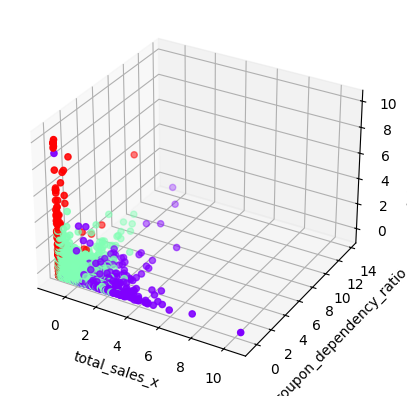

In [27]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(xs = df2['total_sales_x'],ys =  df2['coupon_dependecy_ratio'], zs = df2['relative_recency'], c=df2['cluster'], cmap='rainbow')
ax.set_xlabel('total_sales_x')
ax.set_ylabel('coupon_dependency_ratio')
ax.set_zlabel('relative_recency')
plt.show()

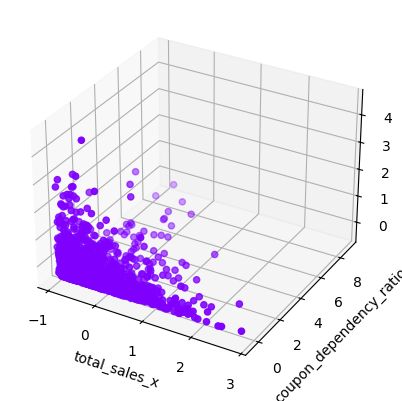

In [28]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(xs = df2[df2['cluster'] == 1]['total_sales_x'],ys =  df2[df2['cluster'] == 1]['coupon_dependecy_ratio'], zs = df2[df2['cluster'] == 1]['relative_recency'], c=df2[df2['cluster'] == 1]['cluster'], cmap='rainbow')
ax.set_xlabel('total_sales_x')
ax.set_ylabel('coupon_dependency_ratio')
ax.set_zlabel('relative_recency')
plt.show()

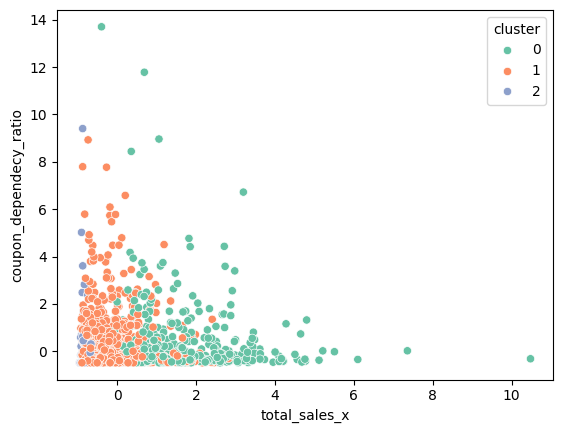

In [29]:
sns.scatterplot(x='total_sales_x', y='coupon_dependecy_ratio', hue='cluster', data=df2, palette = 'Set2')
plt.show()

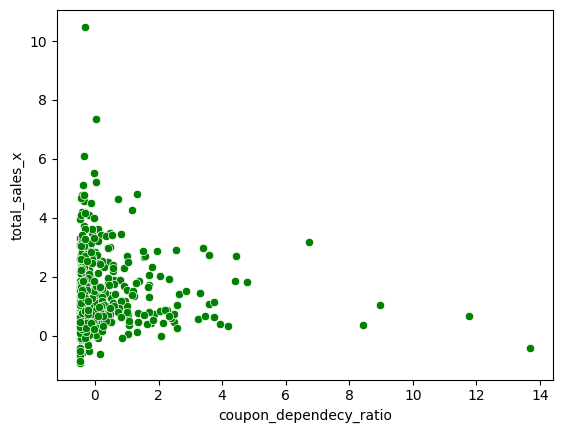

In [30]:
sns.scatterplot(y='total_sales_x', x='coupon_dependecy_ratio', data=df2[df2['cluster'] == 0], color='g')
plt.show()

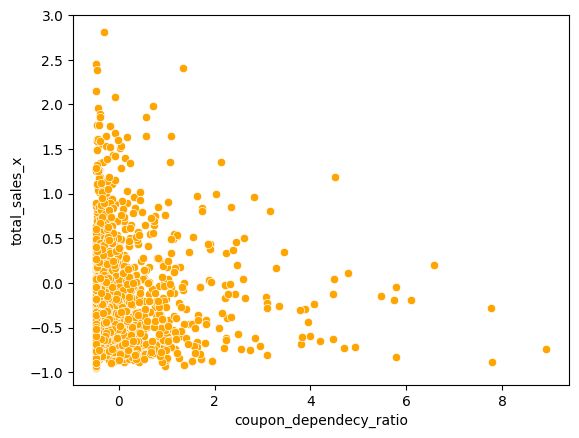

In [31]:
sns.scatterplot(y='total_sales_x', x='coupon_dependecy_ratio', data=df2[df2['cluster'] == 1], palette = 'Set2', color='orange')
plt.show()

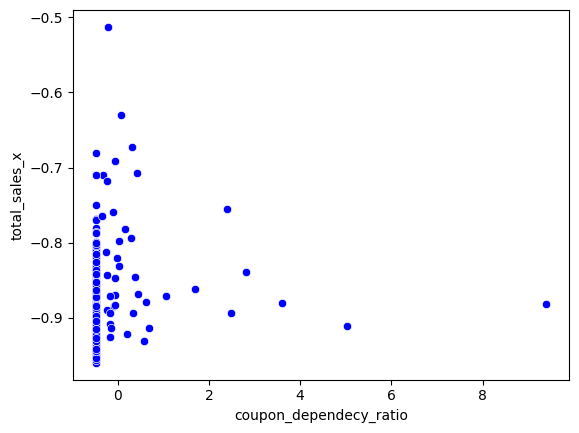

In [32]:
sns.scatterplot(y='total_sales_x', x='coupon_dependecy_ratio', data=df2[df2['cluster'] == 2], palette = 'Set2', color='blue')
plt.show()

In [33]:
df2.head(10)

,total_sales_x,avg_sales,total_quantity,avg_quantity,avg_basket_size,total_orders,unique_visits_days,order_frequency,relative_recency,avg_days_between_visits,coupon_dependecy_ratio,cluster
0,0.330662,-0.642824,-0.418471,-0.374876,-0.567611,-0.212662,-0.146958,-0.342215,-0.327726,-0.310312,2.231985,1
1,-0.378886,-0.410892,-0.423229,-0.374828,-0.571393,-0.567192,-0.592555,-0.071914,0.277581,-0.150210,-0.085853,1
2,-0.170166,-0.269116,-0.391700,-0.341454,-0.439739,-0.549898,-0.579450,-0.072043,-0.279938,-0.140474,2.213599,1
3,-0.604140,0.850390,-0.425079,-0.374412,-0.576073,-0.696898,-0.789142,0.195021,0.930675,0.036920,-0.093612,1
4,-0.729888,0.368244,-0.425639,-0.375094,-0.581405,-0.610427,-0.749825,0.086484,-0.279938,0.082968,-0.484405,1
5,0.828220,0.205436,-0.039214,-0.161655,-0.280742,1.205456,1.714066,-0.630082,-0.343655,-0.516416,-0.459064,0
6,0.052881,-0.505016,-0.420283,-0.374662,-0.565095,-0.446133,-0.409074,-0.122722,-0.375513,-0.186721,0.525189,1
7,0.690484,-0.350667,-0.147055,-0.237277,-0.098427,0.020808,0.167581,-0.448584,-0.327726,-0.386450,0.049075,1
8,-0.724405,0.484651,-0.425197,-0.373028,-0.572106,-0.783368,-0.920200,0.841686,-0.056931,0.496495,-0.432649,1
9,-0.892571,0.205209,-0.426200,-0.373283,-0.576665,-0.878486,-1.116788,2.712968,0.006786,4.530542,-0.484405,2


In [34]:
df2['coupon_dependecy_ratio'].describe()

count    2.500000e+03
mean     4.405365e-17
std      1.000200e+00
min     -4.844055e-01
25%     -4.844055e-01
50%     -3.386990e-01
75%      1.929564e-02
max      1.370062e+01
Name: coupon_dependecy_ratio, dtype: float64

### Business summary

Based on the clustering, we got 3 segments:

**Cluster 0 - Core Loyalists**
- frequent buyers, large volumes, recently shopped
- already engaged, they actively use coupons
- strategy: retention. don't need deep discounts. focus on VIP perks, early access, bundles like `Buy 3 get 1 free`

**Cluster 1 - One-Time & Full-Price Buyers**
- single transaction, no return visit
- paid full price, no coupon usage
- strategy: activation. drive the second purchase with `Welcome Back` offers, first-return discount

**Cluster 2 - Dormant & At-Risk**
- big gaps between visits, low total spend
- have not responded to standard campaigns
- strategy: win-back. steep re-activation discounts, `We Miss You` messaging

1. Total Sales
2. Basket size
3. Total orders
4. Avg days between visits

<Axes: xlabel='cluster', ylabel='avg_days_between_visits'>

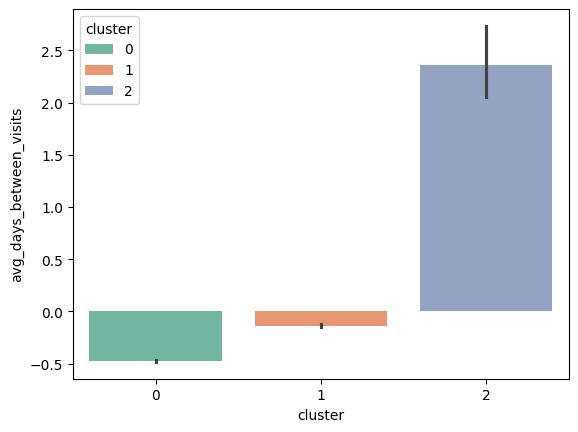

In [35]:
sns.barplot(x='cluster', y='avg_days_between_visits', data=df2, palette = 'Set2', hue='cluster')

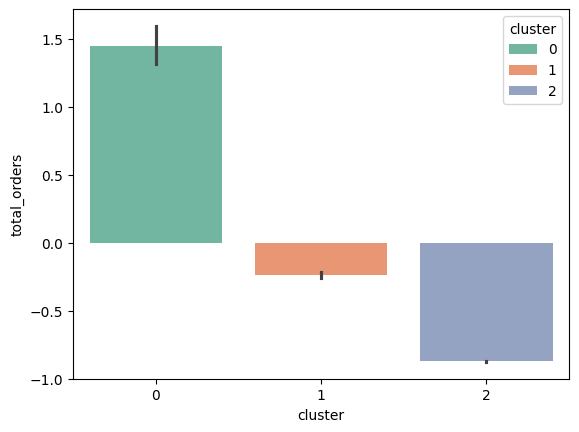

In [36]:
sns.barplot(x='cluster', y='total_orders', data=df2, palette = 'Set2', hue='cluster')
plt.show()

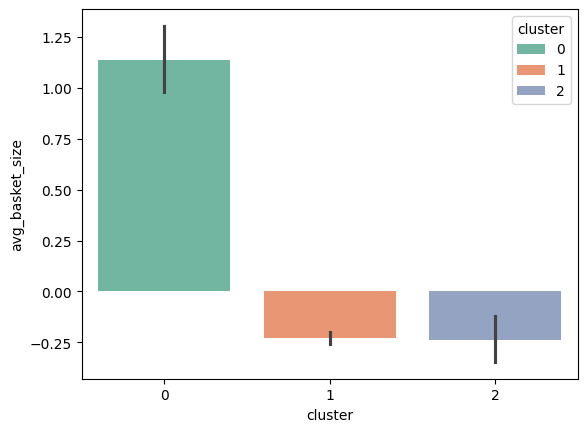

In [37]:
sns.barplot(x='cluster', y='avg_basket_size', data=df2, palette = 'Set2', hue='cluster')
plt.show()

In [38]:
import joblib

joblib.dump(kmeans_3, 'kmeans_3.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(pca, 'pca.joblib')

['pca.joblib']

### Improvements: 

`1. Reasons for the no of clusters selected`  
`2. Reasons for individial features created.`  
`3. Check why these features are correct? - check for multi-collinearity`  
`4. Do clustering based on only RFM features to check if there is an overlap in the clusters.`

In [39]:
df.head()

,household_key,total_sales_x,avg_sales,total_quantity,avg_quantity,avg_basket_size,total_orders,unique_visits_days,order_frequency,relative_recency,avg_days_between_visits,coupon_dependecy_ratio
0,1,4330.16,2.507331,1997,1.156340,23.220930,86,79,7.616279,6,8.397436,0.072399
1,2,1954.34,2.737171,834,1.168067,18.533333,45,45,12.555556,44,12.840909,0.010623
2,3,2653.21,2.877668,8540,9.262473,181.702128,47,46,12.553191,9,13.111111,0.071909
3,4,1200.11,3.987076,382,1.269103,12.733333,30,30,17.433333,85,18.034483,0.010416
4,5,779.06,3.509279,245,1.103604,6.125000,40,33,15.450000,9,19.312500,0.000000


In [40]:
df.shape

(2500, 12)

In [41]:
df2.head()

,total_sales_x,avg_sales,total_quantity,avg_quantity,avg_basket_size,total_orders,unique_visits_days,order_frequency,relative_recency,avg_days_between_visits,coupon_dependecy_ratio,cluster
0,0.330662,-0.642824,-0.418471,-0.374876,-0.567611,-0.212662,-0.146958,-0.342215,-0.327726,-0.310312,2.231985,1
1,-0.378886,-0.410892,-0.423229,-0.374828,-0.571393,-0.567192,-0.592555,-0.071914,0.277581,-0.150210,-0.085853,1
2,-0.170166,-0.269116,-0.391700,-0.341454,-0.439739,-0.549898,-0.579450,-0.072043,-0.279938,-0.140474,2.213599,1
3,-0.604140,0.850390,-0.425079,-0.374412,-0.576073,-0.696898,-0.789142,0.195021,0.930675,0.036920,-0.093612,1
4,-0.729888,0.368244,-0.425639,-0.375094,-0.581405,-0.610427,-0.749825,0.086484,-0.279938,0.082968,-0.484405,1


In [42]:
df2.shape

(2500, 12)

In [43]:
segmented_df = pd.DataFrame()
segmented_df['household_key'] = df['household_key']
segmented_df['cluster'] = df2['cluster']
segmented_df.head()

,household_key,cluster
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


In [44]:
segmented_df.shape

(2500, 2)

In [45]:
segmented_df.to_csv('segmented_df.csv', index=False)